Mengambil data dari Alpha Vantage...
✅ Data berhasil dimuat!
Jumlah baris data : 100

--- 5 Baris Teratas ---


,Open,High,Low,Close,Volume
2025-11-04,3997.51,4000.85,3928.97,3934.81,0.0
2025-11-05,3934.82,3990.56,3929.51,3973.66,0.0
2025-11-06,3973.68,4019.64,3964.64,3989.27,0.0
2025-11-07,3989.17,4027.49,3984.16,4001.56,0.0
2025-11-09,4001.17,4012.20,3997.96,4011.92,0.0


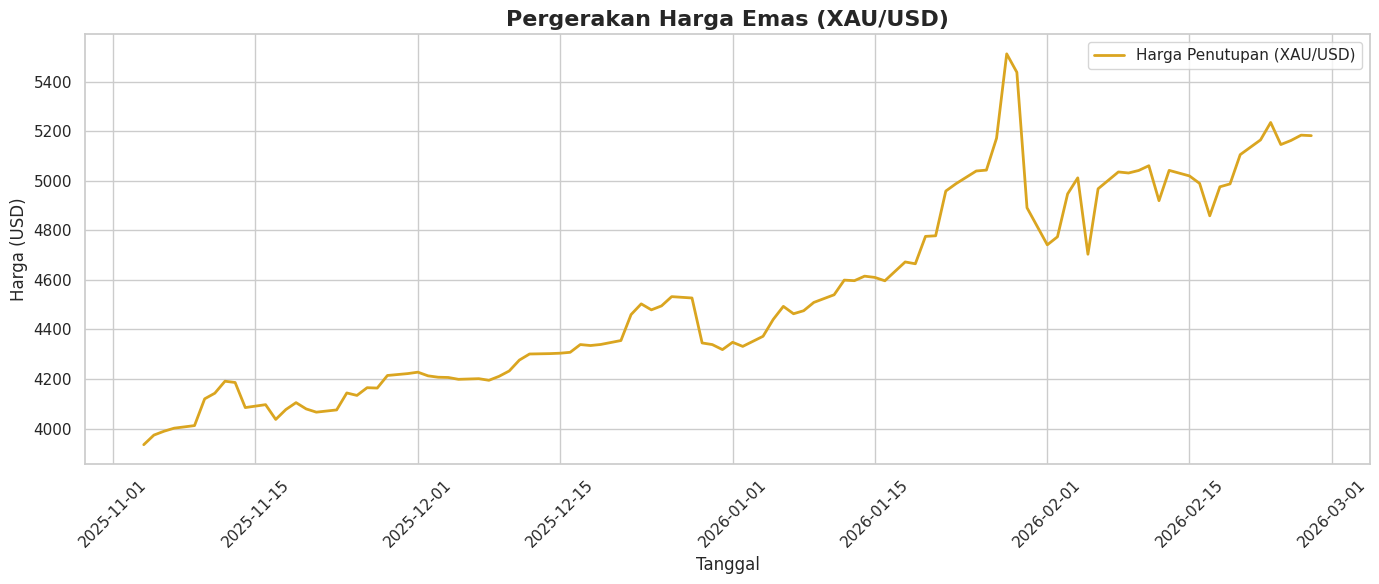

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi agar grafik terlihat profesional
sns.set_theme(style="whitegrid")

# ==========================================
# 1. PENGATURAN API
# ==========================================
API_KEY = "45BR4FHJM2P78TSK" # Nanti saat production, pindahkan ini ke file .env

url = "https://www.alphavantage.co/query"
params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "XAUUSD",
    "outputsize": "compact", # Ganti "full" jika butuh data historis hingga 20 tahun
    "apikey": API_KEY
}

# ==========================================
# 2. PENGAMBILAN DATA
# ==========================================
print("Mengambil data dari Alpha Vantage...")
data = requests.get(url, params=params).json()

# ==========================================
# 3. PENANGANAN ERROR & PEMROSESAN DATA
# ==========================================
if "Error Message" in data:
    print(f"❌ API Error: {data['Error Message']}")
    df = pd.DataFrame()
elif "Information" in data:
    print(f"⚠️ API Limit/Info: {data['Information']}")
    df = pd.DataFrame()
elif "Time Series (Daily)" in data:
    ts = data["Time Series (Daily)"]
    df = pd.DataFrame.from_dict(ts, orient="index")
    
    # Konversi tipe data dan index
    df = df.astype(float)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
    # MERAPIKAN NAMA KOLOM (Menghilangkan angka '1. ', '2. ' bawaan Alpha Vantage)
    df.rename(columns={
        '1. open': 'Open',
        '2. high': 'High',
        '3. low': 'Low',
        '4. close': 'Close',
        '5. volume': 'Volume'
    }, inplace=True)
    
    print("✅ Data berhasil dimuat!")
    print(f"Jumlah baris data : {len(df)}")
    
    # ==========================================
    # 4. MENAMPILKAN DATA & VISUALISASI
    # ==========================================
    print("\n--- 5 Baris Teratas ---")
    display(df.head()) # Menggunakan display() agar tabelnya dirender rapi oleh Jupyter
    
    # Membuat Visualisasi Grafik Garis
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['Close'], color='goldenrod', linewidth=2, label='Harga Penutupan (XAU/USD)')
    
    plt.title('Pergerakan Harga Emas (XAU/USD)', fontsize=16, fontweight='bold')
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()
else:
    print("❌ Format data tidak dikenali atau kosong.")
    df = pd.DataFrame()